## Diseño de redes

In [1]:
import pandas as pd

data = pd.read_excel("data/Tsp-1.xlsx")
data.columns
print(data.iloc[0,:])

colonia          U H FOVISSSTE ESTADI
Calle                          LISBOA
# de casa                          28
Código postal                   44307
Unnamed: 4                Guadalajara
Name: 0, dtype: object


In [42]:
import pandas as pd
from geopy.geocoders import ArcGIS
import time

def pre_procesar_direcciones(ruta_entrada, ruta_salida, cantidad_a_procesar=None):
    df = pd.read_excel(ruta_entrada)
    
    if cantidad_a_procesar:
        df = df.head(cantidad_a_procesar).copy() 
    
    geolocator = ArcGIS()

    lats = []
    lons = []
    encontrados = []

    print(f" Procesando {len(df)} direcciones. ")

    for index, row in df.iterrows():
        calle = str(row['Calle']).replace('#', '').strip()
        numero = str(row['# de casa']).replace('#', '').strip()
        colonia = str(row['colonia']).strip()
        ciudad = str(row['Unnamed: 4']).strip()
        
        direccion = f"{calle} {numero}, {colonia}, {ciudad}, Mexico"
        
        try:
            location = geolocator.geocode(direccion, timeout=10)
            if location:
                lats.append(location.latitude)
                lons.append(location.longitude)
                encontrados.append(True)
                print(f"    {index}: OK")
            else:
                lats.append(None)
                lons.append(None)
                encontrados.append(False)
                print(f"    {index}: No encontrado")
        except:
            lats.append(None)
            lons.append(None)
            encontrados.append(False)
            print(f"    {index}: Error de conexión")

        time.sleep(0.7)

    df['latitud'] = lats
    df['longitud'] = lons
    df["id_original_excel"] = df.index + 1
    
    df_final = df[df['latitud'].notnull()]
    
    df_final.to_csv(ruta_salida, index=False)
    print(f"\n Guardado exitosamente en '{ruta_salida}'. Nodos válidos: {len(df_final)}")

 

In [43]:
pre_procesar_direcciones('data/Tsp-1.xlsx', 'direcciones_lat_lon.csv')

 Procesando 289 direcciones. 
    0: OK
    1: OK
    2: OK
    3: OK
    4: OK
    5: OK
    6: OK
    7: OK
    8: OK
    9: OK
    10: OK
    11: OK
    12: OK
    13: OK
    14: OK
    15: OK
    16: OK
    17: OK
    18: OK
    19: OK
    20: OK
    21: OK
    22: OK
    23: OK
    24: OK
    25: OK
    26: OK
    27: OK
    28: OK
    29: OK
    30: OK
    31: OK
    32: OK
    33: OK
    34: OK
    35: OK
    36: OK
    37: OK
    38: OK
    39: OK
    40: OK
    41: OK
    42: OK
    43: OK
    44: OK
    45: OK
    46: OK
    47: OK
    48: OK
    49: OK
    50: OK
    51: OK
    52: OK
    53: OK
    54: OK
    55: OK
    56: OK
    57: OK
    58: OK
    59: OK
    60: OK
    61: OK
    62: OK
    63: OK
    64: OK
    65: OK
    66: OK
    67: OK
    68: OK
    69: OK
    70: OK
    71: OK
    72: OK
    73: OK
    74: OK
    75: OK
    76: OK
    77: OK
    78: OK
    79: OK
    80: OK
    81: OK
    82: OK
    83: OK
    84: OK
    85: OK
    86: OK
    87: OK
    88: OK
 

In [2]:
import pandas as pd
from geopy.distance import geodesic
from itertools import combinations

def construir_grafo_completo(ruta_csv_procesado, n_nodos, semilla):
    
    df = pd.read_csv(ruta_csv_procesado)
    
    if n_nodos > len(df):
        n_nodos = len(df)
        
    df_random = df.sample(n=n_nodos, random_state=semilla).reset_index(drop=True)

    info_nodos = {}
    coords_list = [] 
    
    for id_nodo, row in df_random.iterrows():
        coords_list.append((id_nodo, row['latitud'], row['longitud']))
        direccion_texto = f"{row.get('Calle', '')} {row.get('# de casa', '')}, {row.get('colonia', '')}"
        
        info_nodos[id_nodo] = {
            'lat': row['latitud'],
            'lon': row['longitud'],
            'nombre': direccion_texto,
            'id_original_excel': row.get('id_original_excel', 'N/A')
        }

    grafo_distancias = {}
    for (id1, lat1, lon1), (id2, lat2, lon2) in combinations(coords_list, 2):
        dist = geodesic((lat1, lon1), (lat2, lon2)).kilometers
        grafo_distancias[(id1, id2)] = round(dist, 4)
        
    return grafo_distancias, info_nodos

## nodo raro

In [3]:
data = pd.read_csv('direcciones_lat_lon.csv')
data

,colonia,Calle,# de casa,Código postal,Unnamed: 4,latitud,longitud,id_original_excel
0,U H FOVISSSTE ESTADI,LISBOA,28,44307,Guadalajara,20.708566,-103.324833,1
1,INDEPENDENCIA,ROGELIO BACON,2280,44290,Guadalajara,20.703739,-103.333463,2
2,BOSQUES D LA CANTERA,PRIV OPALO,17,44306,Guadalajara,20.715599,-103.315732,3
3,JARDINES DE LOS POET,JOSE FERNANDEZ,3365,44820,Guadalajara,20.648511,-103.290044,4
4,LOMAS DEL GALLO,FERNANDO SOLIS,1338,44760,Guadalajara,20.678888,-103.270834,5
...,...,...,...,...,...,...,...,...
284,MESA COLORADA PTE,DELLI,1825,45189,zapopan,20.770435,-103.347895,285
285,VILLA FONTANA DIAMANTE,AV LAS TORRES,1896,45200,zapopan,20.772951,-103.471913,286
286,REAL DE TESISTAN,PASEO DE LA ARB,176,45200,zapopan,20.758770,-103.439228,287
287,EL CENTINELA 2,HIDALGO,310,45187,zapopan,20.605704,-103.424497,288


In [25]:
data = data.drop(data.index[75])
data.to_csv('direcciones_lat_lon_limpio.csv', index=False)

In [26]:
import folium

data = pd.read_csv('direcciones_lat_lon_limpio.csv')
def visualizar_nodos(direcciones_info):
    for row in direcciones_info.itertuples():
        folium.Marker(
            location=[row.latitud, row.longitud],
            popup=f"ID: {row.id_original_excel}\n{row.Calle}, {row.colonia}",
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(mapa)
    return mapa
mapa = folium.Map(location=[data['latitud'].mean(), data['longitud'].mean()], zoom_start=12)
m = visualizar_nodos(data)
m.save("mapa_direcciones.html")

In [23]:
data[data["Calle"] == "TERUEL"]

,colonia,Calle,# de casa,Código postal,Unnamed: 4,latitud,longitud,id_original_excel
75,DIVISION DEL NORTE,TERUEL,3693,44230,Guadalajara,31.726363,-106.509601,78


## Algoritmo genético

In [ ]:
import random
import time
import operator

def calcular_fitness(ruta, grafo_distancias):
    """
    Calcula la distancia total de una ruta.
    Fitness = 1 / Distancia (porque queremos minimizar distancia).
    """
    distancia_total = 0
    for i in range(len(ruta)):
        origen = ruta[i]
        destino = ruta[(i + 1) % len(ruta)]
        
        if (origen, destino) in grafo_distancias:
            distancia_total += grafo_distancias[(origen, destino)]
        elif (destino, origen) in grafo_distancias:
            distancia_total += grafo_distancias[(destino, origen)]
        else:
            distancia_total += 999999 
            
    return distancia_total, 1 / distancia_total

def crear_poblacion(tam_poblacion, lista_nodos_ids):
    poblacion = []
    for _ in range(tam_poblacion):
        individuo = random.sample(lista_nodos_ids, len(lista_nodos_ids))
        poblacion.append(individuo)
    return poblacion

def seleccion_ruleta(poblacion, fitness_resultados):
    """
    Selecciona padres basándose en su probabilidad (Fitness relativo).
    """
    scores = [f[1] for f in fitness_resultados]
    sum_scores = sum(scores)
    
    probs = [s / sum_scores for s in scores]
    
    seleccionados = random.choices(poblacion, weights=probs, k=len(poblacion))
    return seleccionados

def cruzar_ox1(padre1, padre2):
    """
    Cruce especial para TSP. Mantiene una sub-sección del padre 1
    y rellena con el padre 2 en orden, evitando duplicados.
    """
    size = len(padre1)
    
    punto1 = random.randint(0, size - 1)
    punto2 = random.randint(0, size - 1)
    
    inicio = min(punto1, punto2)
    fin = max(punto1, punto2)
    
    hijo = [None] * size
    hijo[inicio:fin+1] = padre1[inicio:fin+1]
    
    pos_actual = 0
    for ciudad in padre2:
        if ciudad not in hijo:
            while hijo[pos_actual] is not None:
                pos_actual += 1
            hijo[pos_actual] = ciudad
            
    return hijo

def mutar(individuo, tasa_mutacion):
    """Intercambia dos ciudades de lugar al azar."""
    if random.random() < tasa_mutacion:
        idx1, idx2 = random.sample(range(len(individuo)), 2)
        individuo[idx1], individuo[idx2] = individuo[idx2], individuo[idx1]
    return individuo


def algoritmo_genetico_tsp(grafo_distancias, lista_nodos_ids, tam_poblacion, generaciones, tasa_mutacion, elite_size):
    
    start_time = time.time()
    
    poblacion = crear_poblacion(tam_poblacion, lista_nodos_ids)
    
    mejor_ruta_global = None
    mejor_distancia_global = float('inf')
    
    for i in range(generaciones):
        resultados_fitness = []
        for individuo in poblacion:
            dist, score = calcular_fitness(individuo, grafo_distancias)
            resultados_fitness.append((dist, score))
            
            if dist < mejor_distancia_global:
                mejor_distancia_global = dist
                mejor_ruta_global = individuo[:] 
        
        ordenados = sorted(zip(poblacion, resultados_fitness), key=lambda x: x[1][0])
        nueva_poblacion = [x[0] for x in ordenados[:elite_size]]

        pool_padres = seleccion_ruleta(poblacion, resultados_fitness)
        
        while len(nueva_poblacion) < tam_poblacion:
            padre_a = random.choice(pool_padres)
            padre_b = random.choice(pool_padres)
            
            hijo = cruzar_ox1(padre_a, padre_b)
            hijo = mutar(hijo, tasa_mutacion)
            
            nueva_poblacion.append(hijo)
            
        poblacion = nueva_poblacion

    end_time = time.time()
    tiempo_computo = end_time - start_time
    
    return {
        'mejor_ruta': mejor_ruta_global,
        'mejor_distancia': mejor_distancia_global,
        'tiempo_segundos': round(tiempo_computo, 4)
    }


def seleccion_torneo(poblacion, fitness_resultados, k=3):
    """
    Elige 'k' individuos al azar y se queda con el mejor de esos 'k'.
    Repite hasta llenar la piscina de padres.
    """
    seleccionados = []
    tam = len(poblacion)
    
    for _ in range(tam):
        competidores = random.sample(list(zip(poblacion, fitness_resultados)), k)
        
        ganador = min(competidores, key=lambda x: x[1][0]) 
        
        seleccionados.append(ganador[0])
        
    return seleccionados

def mutar_inversion(individuo, tasa_mutacion):
    """
    En lugar de cambiar A por B, invierte el segmento A...B.
    Esto deshace los cruces en la ruta (efecto 2-opt).
    """
    if random.random() < tasa_mutacion:
        idx1, idx2 = random.sample(range(len(individuo)), 2)
        
        inicio = min(idx1, idx2)
        fin = max(idx1, idx2)
        
        individuo[inicio:fin+1] = individuo[inicio:fin+1][::-1]
        
    return individuo

def algoritmo_genetico_tsp_mejorado(grafo_distancias, lista_nodos_ids, tam_poblacion, generaciones, tasa_mutacion, elite_size):
    start_time = time.time()
    
    poblacion = crear_poblacion(tam_poblacion, lista_nodos_ids)
    
    mejor_ruta_global = None
    mejor_distancia_global = float('inf')
    
    for i in range(generaciones):

        resultados_fitness = []
        for individuo in poblacion:
            dist, score = calcular_fitness(individuo, grafo_distancias)
            resultados_fitness.append((dist, score))
            
            if dist < mejor_distancia_global:
                mejor_distancia_global = dist
                mejor_ruta_global = individuo[:]

        ordenados = sorted(zip(poblacion, resultados_fitness), key=lambda x: x[1][0])
        nueva_poblacion = [x[0] for x in ordenados[:elite_size]]
        
        pool_padres = seleccion_torneo(poblacion, resultados_fitness, k=3)
        
        while len(nueva_poblacion) < tam_poblacion:
            padre_a = random.choice(pool_padres)
            padre_b = random.choice(pool_padres)
            
            hijo = cruzar_ox1(padre_a, padre_b)
            
            hijo = mutar_inversion(hijo, tasa_mutacion)
            
            nueva_poblacion.append(hijo)
            
        poblacion = nueva_poblacion

    end_time = time.time()
    
    return {
        'mejor_ruta': mejor_ruta_global,
        'mejor_distancia': mejor_distancia_global,
        'tiempo_segundos': round(end_time - start_time, 4)
    }

## Hormigas

In [28]:
import numpy as np
import random
import time

def inicializar_feromonas(n_nodos, feromona_inicial=1.0):
    """Inicializa la matriz de feromonas con un valor uniforme."""
    return np.full((n_nodos, n_nodos), feromona_inicial)

def calcular_heuristica(grafo_distancias, n_nodos):
    """
    Calcula la información heurística (eta): 1 / distancia.
    Protegida contra distancias cero.
    """
    heuristica = np.zeros((n_nodos, n_nodos))
    epsilon = 0.0001 
    
    for i in range(n_nodos):
        for j in range(n_nodos):
            if i != j:
                distancia = grafo_distancias.get((i, j), grafo_distancias.get((j, i), -1))
                if distancia <= 0:
                    distancia = epsilon 
                
                # Eta
                heuristica[i, j] = 1.0 / distancia
                
    return heuristica

def seleccionar_siguiente_ciudad(actual, ciudades_permitidas, feromonas, heuristica, alpha, beta):
    """Implementa la regla de probabilidad de transición (Ruleta de ACO)."""
    
    numeradores = []
    
    for siguiente in ciudades_permitidas:
        tau = feromonas[actual, siguiente]
        eta = heuristica[actual, siguiente]
        
        numerador = (tau ** alpha) * (eta ** beta)
        numeradores.append(numerador)
        
    denominador = sum(numeradores)
    
    if denominador == 0:
        return random.choice(ciudades_permitidas)
        
    probabilidades = [n / denominador for n in numeradores]
    
    seleccion = random.choices(ciudades_permitidas, weights=probabilidades, k=1)[0]
    return seleccion

In [29]:
def aco_tsp(grafo_distancias, n_nodos,
            n_hormigas, n_iteraciones, feromona_inicial=1.0, Q=1.0,
            alpha=1.0, beta=2.0, rho=0.5):
    """
    Algoritmo de Colonia de Hormigas para el TSP.
    
    Parámetros:
    Q: Cantidad de feromona depositada.
    alpha: Peso de la feromona (tau).
    beta: Peso de la información heurística (eta).
    rho: Tasa de evaporación.
    """
    
    start_time = time.time()
    
    feromonas = inicializar_feromonas(n_nodos, feromona_inicial)
    heuristica = calcular_heuristica(grafo_distancias, n_nodos)
    
    mejor_distancia_global = float('inf')
    mejor_ruta_global = None
    
    lista_nodos_ids = list(range(n_nodos))
    
    for iteracion in range(n_iteraciones):
        rutas_colonia = []
        distancias_colonia = []
        
        for _ in range(n_hormigas):
            ruta = [random.choice(lista_nodos_ids)] 
            ciudades_permitidas = set(lista_nodos_ids) - {ruta[0]}
            
            actual = ruta[0]
            
            while ciudades_permitidas:
                siguiente = seleccionar_siguiente_ciudad(
                    actual, list(ciudades_permitidas), feromonas, heuristica, alpha, beta
                )
                ruta.append(siguiente)
                ciudades_permitidas.remove(siguiente)
                actual = siguiente
                
            ruta.append(ruta[0]) 
            
            distancia, _ = calcular_fitness(ruta[:-1], grafo_distancias) 
            
            rutas_colonia.append(ruta)
            distancias_colonia.append(distancia)
            
            if distancia < mejor_distancia_global:
                mejor_distancia_global = distancia
                mejor_ruta_global = ruta

        # Evaporación: tau_ij = (1 - rho) * tau_ij
        feromonas = feromonas * (1 - rho)
        
        # Depósito (usando el modelo Q/L_k)
        for k in range(n_hormigas):
            ruta = rutas_colonia[k]
            L_k = distancias_colonia[k]
            delta_tau = Q / L_k
            
            for i in range(len(ruta) - 1):
                u, v = ruta[i], ruta[i+1]
                feromonas[u, v] += delta_tau
                feromonas[v, u] += delta_tau 
                
    end_time = time.time()
    tiempo_computo = end_time - start_time
    
    return {
        'mejor_ruta': mejor_ruta_global,
        'mejor_distancia': mejor_distancia_global,
        'tiempo_segundos': round(tiempo_computo, 4)
    }


## 10 grafos de 40 nodos

In [42]:
grafos_40 = []


for i in range(10):
    distancias, metadatos = construir_grafo_completo("direcciones_lat_lon_limpio.csv", 40, semilla=i)
    
    experimento = {
        'id_experimento': i,
        'distancias': distancias,  
        'info_nodos': metadatos,  
        'ruta_optima': None,       
        'costo_total': 0           #
    }
    
    grafos_40.append(experimento)




In [57]:
"""PARAMS = {
    'tam_poblacion': 100,
    'generaciones': 200,    
    'tasa_mutacion': 0.1, 
    'elite_size': 10      
}
"""

PARAMS = {
    'tam_poblacion': 150,    
    'generaciones': 500,   
    'tasa_mutacion': 0.1,   
    'elite_size': 15
}

print(f" Iniciando Algoritmo Genético en {len(grafos_40)} grafos...")

for exp in grafos_40:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = algoritmo_genetico_tsp_mejorado(
        grafo_distancias=grafo,
        lista_nodos_ids=lista_ids,
        tam_poblacion=PARAMS['tam_poblacion'],
        generaciones=PARAMS['generaciones'],
        tasa_mutacion=PARAMS['tasa_mutacion'],
        elite_size=PARAMS['elite_size']
    )
    
    exp['ruta_optima_AG'] = resultado['mejor_ruta']
    exp['costo_total_AG'] = resultado['mejor_distancia']
    exp['tiempo_computo_AG'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")


 Iniciando Algoritmo Genético en 10 grafos...
Exp 0: Distancia 110.14km | Tiempo: 2.941s
Exp 1: Distancia 137.85km | Tiempo: 2.9542s
Exp 2: Distancia 86.44km | Tiempo: 2.7821s
Exp 3: Distancia 99.29km | Tiempo: 2.6692s
Exp 4: Distancia 121.34km | Tiempo: 2.5901s
Exp 5: Distancia 110.95km | Tiempo: 2.6059s
Exp 6: Distancia 103.57km | Tiempo: 2.7963s
Exp 7: Distancia 108.08km | Tiempo: 3.9988s
Exp 8: Distancia 100.20km | Tiempo: 3.4996s
Exp 9: Distancia 120.82km | Tiempo: 3.1336s


In [58]:


print(f" Iniciando Hormigas en {len(grafos_40)} grafos...")

for exp in grafos_40:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = aco_tsp(
        grafo_distancias=grafo,
        n_nodos=len(lista_ids),
        n_hormigas=50,
        n_iteraciones=100,
        feromona_inicial=1.0,
        Q=1.0,
        alpha=1.0,
        beta=2.0,
        rho=0.5
    )
    
    exp['ruta_optima_H'] = resultado['mejor_ruta']
    exp['costo_total_H'] = resultado['mejor_distancia']
    exp['tiempo_computo_H'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")


 Iniciando Hormigas en 10 grafos...
Exp 0: Distancia 107.89km | Tiempo: 4.7141s
Exp 1: Distancia 134.25km | Tiempo: 4.2845s
Exp 2: Distancia 86.83km | Tiempo: 3.4622s
Exp 3: Distancia 95.04km | Tiempo: 3.3253s
Exp 4: Distancia 122.67km | Tiempo: 5.1718s
Exp 5: Distancia 103.63km | Tiempo: 6.1326s
Exp 6: Distancia 103.92km | Tiempo: 6.4727s
Exp 7: Distancia 106.63km | Tiempo: 6.8785s
Exp 8: Distancia 100.37km | Tiempo: 6.8315s
Exp 9: Distancia 123.54km | Tiempo: 6.0657s


In [59]:
grafos_40[1]

{'id_experimento': 1,
 'distancias': {(0, 1): 5.4562,
  (0, 2): 6.2627,
  (0, 3): 11.1163,
  (0, 4): 2.0512,
  (0, 5): 11.4297,
  (0, 6): 10.2222,
  (0, 7): 16.3967,
  (0, 8): 3.6548,
  (0, 9): 7.7777,
  (0, 10): 9.2828,
  (0, 11): 10.0177,
  (0, 12): 3.0608,
  (0, 13): 2.0612,
  (0, 14): 3.3882,
  (0, 15): 11.4705,
  (0, 16): 2.1628,
  (0, 17): 4.8859,
  (0, 18): 14.6383,
  (0, 19): 18.8588,
  (0, 20): 16.5056,
  (0, 21): 20.8805,
  (0, 22): 3.3493,
  (0, 23): 16.1212,
  (0, 24): 4.833,
  (0, 25): 22.2181,
  (0, 26): 1.693,
  (0, 27): 8.6933,
  (0, 28): 9.1512,
  (0, 29): 10.176,
  (0, 30): 13.2236,
  (0, 31): 0.7787,
  (0, 32): 3.8402,
  (0, 33): 10.4662,
  (0, 34): 6.0723,
  (0, 35): 9.942,
  (0, 36): 5.3322,
  (0, 37): 15.3481,
  (0, 38): 1.0004,
  (0, 39): 14.0666,
  (1, 2): 8.3163,
  (1, 3): 7.7394,
  (1, 4): 4.0502,
  (1, 5): 12.1615,
  (1, 6): 13.742,
  (1, 7): 11.7724,
  (1, 8): 7.7523,
  (1, 9): 3.0973,
  (1, 10): 5.9811,
  (1, 11): 9.4931,
  (1, 12): 2.779,
  (1, 13): 4.0322

## 10 grafos con 100 nodos

In [63]:

grafos_100 = []


for i in range(10):
    distancias, metadatos = construir_grafo_completo("direcciones_lat_lon_limpio.csv",100, semilla=i)
    
    experimento = {
        'id_experimento': i,
        'distancias': distancias,  
        'info_nodos': metadatos,  
        'ruta_optima': None,       
        'costo_total': 0           
    }
    
    grafos_100.append(experimento)



PARAMS = {
    'tam_poblacion': 300,    
    'generaciones': 500,   
    'tasa_mutacion': 0.1,   
    'elite_size': 15
}

print(f" Iniciando Algoritmo Genético en {len(grafos_100)} grafos...")

for exp in grafos_100:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = algoritmo_genetico_tsp(
        grafo_distancias=grafo,
        lista_nodos_ids=lista_ids,
        tam_poblacion=PARAMS['tam_poblacion'],
        generaciones=PARAMS['generaciones'],
        tasa_mutacion=PARAMS['tasa_mutacion'],
        elite_size=PARAMS['elite_size']
    )
    
    exp['ruta_optima_AG'] = resultado['mejor_ruta']
    exp['costo_total_AG'] = resultado['mejor_distancia']
    exp['tiempo_computo_AG'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")



print(f" Iniciando Hormigas en {len(grafos_100)} grafos...")

for exp in grafos_100:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = aco_tsp(
        grafo_distancias=grafo,
        n_nodos=len(lista_ids),
        n_hormigas=50,
        n_iteraciones=100,
        feromona_inicial=1.0,
        Q=1.0,
        alpha=1.0,
        beta=2.0,
        rho=0.5
    )
    
    exp['ruta_optima_H'] = resultado['mejor_ruta']
    exp['costo_total_H'] = resultado['mejor_distancia']
    exp['tiempo_computo_H'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")

grafos_100[1]

 Iniciando Algoritmo Genético en 10 grafos...
Exp 0: Distancia 443.06km | Tiempo: 212.9133s
Exp 1: Distancia 522.78km | Tiempo: 198.4487s
Exp 2: Distancia 467.61km | Tiempo: 136.253s
Exp 3: Distancia 434.37km | Tiempo: 69.4907s
Exp 4: Distancia 477.74km | Tiempo: 82.5824s
Exp 5: Distancia 479.42km | Tiempo: 64.2101s
Exp 6: Distancia 511.10km | Tiempo: 59.4102s
Exp 7: Distancia 474.92km | Tiempo: 55.8694s
Exp 8: Distancia 569.40km | Tiempo: 58.2687s
Exp 9: Distancia 465.78km | Tiempo: 52.6059s
 Iniciando Hormigas en 10 grafos...
Exp 0: Distancia 185.75km | Tiempo: 30.0578s
Exp 1: Distancia 215.58km | Tiempo: 24.2403s
Exp 2: Distancia 159.83km | Tiempo: 24.0771s
Exp 3: Distancia 171.10km | Tiempo: 34.6009s
Exp 4: Distancia 185.69km | Tiempo: 32.0646s
Exp 5: Distancia 203.61km | Tiempo: 33.3957s
Exp 6: Distancia 196.65km | Tiempo: 26.5534s
Exp 7: Distancia 206.94km | Tiempo: 25.5732s
Exp 8: Distancia 236.92km | Tiempo: 25.0184s
Exp 9: Distancia 173.74km | Tiempo: 24.4654s


{'id_experimento': 1,
 'distancias': {(0, 1): 5.4562,
  (0, 2): 6.2627,
  (0, 3): 11.1163,
  (0, 4): 2.0512,
  (0, 5): 11.4297,
  (0, 6): 10.2222,
  (0, 7): 16.3967,
  (0, 8): 3.6548,
  (0, 9): 7.7777,
  (0, 10): 9.2828,
  (0, 11): 10.0177,
  (0, 12): 3.0608,
  (0, 13): 2.0612,
  (0, 14): 3.3882,
  (0, 15): 11.4705,
  (0, 16): 2.1628,
  (0, 17): 4.8859,
  (0, 18): 14.6383,
  (0, 19): 18.8588,
  (0, 20): 16.5056,
  (0, 21): 20.8805,
  (0, 22): 3.3493,
  (0, 23): 16.1212,
  (0, 24): 4.833,
  (0, 25): 22.2181,
  (0, 26): 1.693,
  (0, 27): 8.6933,
  (0, 28): 9.1512,
  (0, 29): 10.176,
  (0, 30): 13.2236,
  (0, 31): 0.7787,
  (0, 32): 3.8402,
  (0, 33): 10.4662,
  (0, 34): 6.0723,
  (0, 35): 9.942,
  (0, 36): 5.3322,
  (0, 37): 15.3481,
  (0, 38): 1.0004,
  (0, 39): 14.0666,
  (0, 40): 7.3077,
  (0, 41): 9.295,
  (0, 42): 11.0574,
  (0, 43): 3.7727,
  (0, 44): 0.6912,
  (0, 45): 5.02,
  (0, 46): 2.3528,
  (0, 47): 8.4285,
  (0, 48): 4.8088,
  (0, 49): 7.8241,
  (0, 50): 11.3633,
  (0, 51): 

## 10 grafos con 150 nodos

In [65]:

grafos_150 = []


for i in range(10):
    distancias, metadatos = construir_grafo_completo("direcciones_lat_lon_limpio.csv",150, semilla=i)
    
    experimento = {
        'id_experimento': i,
        'distancias': distancias,  
        'info_nodos': metadatos,  
        'ruta_optima': None,       
        'costo_total': 0           #
    }
    
    grafos_150.append(experimento)



PARAMS = {
    'tam_poblacion': 500,    
    'generaciones': 800,   
    'tasa_mutacion': 0.1,   
    'elite_size': 15
}

print(f" Iniciando Algoritmo Genético en {len(grafos_150)} grafos...")

for exp in grafos_150:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = algoritmo_genetico_tsp_mejorado(
        grafo_distancias=grafo,
        lista_nodos_ids=lista_ids,
        tam_poblacion=PARAMS['tam_poblacion'],
        generaciones=PARAMS['generaciones'],
        tasa_mutacion=PARAMS['tasa_mutacion'],
        elite_size=PARAMS['elite_size']
    )
    
    exp['ruta_optima_AG'] = resultado['mejor_ruta']
    exp['costo_total_AG'] = resultado['mejor_distancia']
    exp['tiempo_computo_AG'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")



print(f" Iniciando Hormigas en {len(grafos_150)} grafos...")

for exp in grafos_150:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = aco_tsp(
        grafo_distancias=grafo,
        n_nodos=len(lista_ids),
        n_hormigas=50,
        n_iteraciones=100,
        feromona_inicial=1.0,
        Q=1.0,
        alpha=1.0,
        beta=2.0,
        rho=0.5
    )
    
    exp['ruta_optima_H'] = resultado['mejor_ruta']
    exp['costo_total_H'] = resultado['mejor_distancia']
    exp['tiempo_computo_H'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")

grafos_150[1]

 Iniciando Algoritmo Genético en 10 grafos...
Exp 0: Distancia 227.55km | Tiempo: 134.0037s
Exp 1: Distancia 280.90km | Tiempo: 161.0426s
Exp 2: Distancia 230.73km | Tiempo: 194.1369s
Exp 3: Distancia 208.08km | Tiempo: 143.8175s
Exp 4: Distancia 279.07km | Tiempo: 173.1104s
Exp 5: Distancia 241.93km | Tiempo: 174.1576s
Exp 6: Distancia 260.42km | Tiempo: 136.508s
Exp 7: Distancia 244.23km | Tiempo: 135.437s
Exp 8: Distancia 287.25km | Tiempo: 135.6803s
Exp 9: Distancia 258.66km | Tiempo: 150.9582s
 Iniciando Hormigas en 10 grafos...
Exp 0: Distancia 225.99km | Tiempo: 74.218s
Exp 1: Distancia 275.14km | Tiempo: 54.6369s
Exp 2: Distancia 223.42km | Tiempo: 53.0223s
Exp 3: Distancia 205.80km | Tiempo: 52.2258s
Exp 4: Distancia 270.29km | Tiempo: 58.6784s
Exp 5: Distancia 236.00km | Tiempo: 53.9627s
Exp 6: Distancia 243.34km | Tiempo: 54.6544s
Exp 7: Distancia 239.75km | Tiempo: 68.1157s
Exp 8: Distancia 270.08km | Tiempo: 53.9725s
Exp 9: Distancia 244.76km | Tiempo: 57.2598s


{'id_experimento': 1,
 'distancias': {(0, 1): 5.4562,
  (0, 2): 6.2627,
  (0, 3): 11.1163,
  (0, 4): 2.0512,
  (0, 5): 11.4297,
  (0, 6): 10.2222,
  (0, 7): 16.3967,
  (0, 8): 3.6548,
  (0, 9): 7.7777,
  (0, 10): 9.2828,
  (0, 11): 10.0177,
  (0, 12): 3.0608,
  (0, 13): 2.0612,
  (0, 14): 3.3882,
  (0, 15): 11.4705,
  (0, 16): 2.1628,
  (0, 17): 4.8859,
  (0, 18): 14.6383,
  (0, 19): 18.8588,
  (0, 20): 16.5056,
  (0, 21): 20.8805,
  (0, 22): 3.3493,
  (0, 23): 16.1212,
  (0, 24): 4.833,
  (0, 25): 22.2181,
  (0, 26): 1.693,
  (0, 27): 8.6933,
  (0, 28): 9.1512,
  (0, 29): 10.176,
  (0, 30): 13.2236,
  (0, 31): 0.7787,
  (0, 32): 3.8402,
  (0, 33): 10.4662,
  (0, 34): 6.0723,
  (0, 35): 9.942,
  (0, 36): 5.3322,
  (0, 37): 15.3481,
  (0, 38): 1.0004,
  (0, 39): 14.0666,
  (0, 40): 7.3077,
  (0, 41): 9.295,
  (0, 42): 11.0574,
  (0, 43): 3.7727,
  (0, 44): 0.6912,
  (0, 45): 5.02,
  (0, 46): 2.3528,
  (0, 47): 8.4285,
  (0, 48): 4.8088,
  (0, 49): 7.8241,
  (0, 50): 11.3633,
  (0, 51): 

## 10 grafos con 200 nodos

In [66]:

grafos_200 = []


for i in range(10):
    distancias, metadatos = construir_grafo_completo("direcciones_lat_lon_limpio.csv",200, semilla=i)
    
    experimento = {
        'id_experimento': i,
        'distancias': distancias,  
        'info_nodos': metadatos,  
        'ruta_optima': None,       
        'costo_total': 0           #
    }
    
    grafos_200.append(experimento)



PARAMS = {
    'tam_poblacion': 500,    
    'generaciones': 1000,   
    'tasa_mutacion': 0.1,   
    'elite_size': 20
}

print(f" Iniciando Algoritmo Genético en {len(grafos_200)} grafos...")

for exp in grafos_200:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = algoritmo_genetico_tsp_mejorado(
        grafo_distancias=grafo,
        lista_nodos_ids=lista_ids,
        tam_poblacion=PARAMS['tam_poblacion'],
        generaciones=PARAMS['generaciones'],
        tasa_mutacion=PARAMS['tasa_mutacion'],
        elite_size=PARAMS['elite_size']
    )
    
    exp['ruta_optima_AG'] = resultado['mejor_ruta']
    exp['costo_total_AG'] = resultado['mejor_distancia']
    exp['tiempo_computo_AG'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")



print(f" Iniciando Hormigas en {len(grafos_200)} grafos...")

for exp in grafos_200:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = aco_tsp(
        grafo_distancias=grafo,
        n_nodos=len(lista_ids),
        n_hormigas=50,
        n_iteraciones=100,
        feromona_inicial=1.0,
        Q=1.0,
        alpha=1.0,
        beta=2.0,
        rho=0.5
    )
    
    exp['ruta_optima_H'] = resultado['mejor_ruta']
    exp['costo_total_H'] = resultado['mejor_distancia']
    exp['tiempo_computo_H'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")

grafos_150[1]

 Iniciando Algoritmo Genético en 10 grafos...
Exp 0: Distancia 327.34km | Tiempo: 256.5003s
Exp 1: Distancia 325.70km | Tiempo: 243.9821s
Exp 2: Distancia 280.40km | Tiempo: 246.6442s
Exp 3: Distancia 293.24km | Tiempo: 265.8863s
Exp 4: Distancia 321.59km | Tiempo: 338.9398s
Exp 5: Distancia 292.27km | Tiempo: 306.4423s
Exp 6: Distancia 299.81km | Tiempo: 363.8592s
Exp 7: Distancia 286.22km | Tiempo: 391.7095s
Exp 8: Distancia 317.18km | Tiempo: 479.1488s
Exp 9: Distancia 337.70km | Tiempo: 288.9099s
 Iniciando Hormigas en 10 grafos...
Exp 0: Distancia 310.62km | Tiempo: 103.3749s
Exp 1: Distancia 305.56km | Tiempo: 107.7593s
Exp 2: Distancia 257.87km | Tiempo: 136.3167s
Exp 3: Distancia 292.16km | Tiempo: 216.9973s
Exp 4: Distancia 308.73km | Tiempo: 157.7406s
Exp 5: Distancia 290.93km | Tiempo: 141.4003s
Exp 6: Distancia 289.73km | Tiempo: 177.7243s
Exp 7: Distancia 285.09km | Tiempo: 187.3498s
Exp 8: Distancia 305.69km | Tiempo: 150.9686s
Exp 9: Distancia 310.15km | Tiempo: 114.3333

{'id_experimento': 1,
 'distancias': {(0, 1): 5.4562,
  (0, 2): 6.2627,
  (0, 3): 11.1163,
  (0, 4): 2.0512,
  (0, 5): 11.4297,
  (0, 6): 10.2222,
  (0, 7): 16.3967,
  (0, 8): 3.6548,
  (0, 9): 7.7777,
  (0, 10): 9.2828,
  (0, 11): 10.0177,
  (0, 12): 3.0608,
  (0, 13): 2.0612,
  (0, 14): 3.3882,
  (0, 15): 11.4705,
  (0, 16): 2.1628,
  (0, 17): 4.8859,
  (0, 18): 14.6383,
  (0, 19): 18.8588,
  (0, 20): 16.5056,
  (0, 21): 20.8805,
  (0, 22): 3.3493,
  (0, 23): 16.1212,
  (0, 24): 4.833,
  (0, 25): 22.2181,
  (0, 26): 1.693,
  (0, 27): 8.6933,
  (0, 28): 9.1512,
  (0, 29): 10.176,
  (0, 30): 13.2236,
  (0, 31): 0.7787,
  (0, 32): 3.8402,
  (0, 33): 10.4662,
  (0, 34): 6.0723,
  (0, 35): 9.942,
  (0, 36): 5.3322,
  (0, 37): 15.3481,
  (0, 38): 1.0004,
  (0, 39): 14.0666,
  (0, 40): 7.3077,
  (0, 41): 9.295,
  (0, 42): 11.0574,
  (0, 43): 3.7727,
  (0, 44): 0.6912,
  (0, 45): 5.02,
  (0, 46): 2.3528,
  (0, 47): 8.4285,
  (0, 48): 4.8088,
  (0, 49): 7.8241,
  (0, 50): 11.3633,
  (0, 51): 

## Ejemplo

In [35]:
import folium

def graficar_comparacion_rutas(id_experimento, lista_resultados):
    datos = lista_resultados[id_experimento]
    nodos = datos['info_nodos']
    ruta_ag = datos.get('ruta_optima_AG', [])
    costo_ag = datos.get('costo_total_AG', 0)
    
    ruta_h = datos.get('ruta_optima_H', [])
    costo_h = datos.get('costo_total_H', 0)

    primer_id = list(nodos.keys())[0]
    centro_lat = nodos[primer_id]['lat']
    centro_lon = nodos[primer_id]['lon']
    
    m = folium.Map(location=[centro_lat, centro_lon], zoom_start=13)

    fg_nodos = folium.FeatureGroup(name="Nodos (Ciudades)")
    
    for nodo_id, info in nodos.items():
        folium.CircleMarker(
            location=[info['lat'], info['lon']],
            radius=5,
            color="black",
            fill=True,
            fill_color="white",
            popup=f"<b>ID: {nodo_id}</b><br>{info['nombre']}",
            tooltip=f"Nodo {nodo_id}"
        ).add_to(fg_nodos)
    
    fg_nodos.add_to(m)

    def obtener_coords_ruta(lista_ids_ruta):
        coords = []
        if not lista_ids_ruta: return []
        
        for nid in lista_ids_ruta:
            lat = nodos[nid]['lat']
            lon = nodos[nid]['lon']
            coords.append((lat, lon))
            
        if lista_ids_ruta[0] != lista_ids_ruta[-1]:
            coords.append(coords[0])
            
        return coords

    coords_ag = obtener_coords_ruta(ruta_ag)
    fg_ag = folium.FeatureGroup(name=f"Genético ({costo_ag:.1f} km)")
    
    folium.PolyLine(
        coords_ag, 
        color="blue", 
        weight=4, 
        opacity=0.6,
        tooltip=f"Ruta AG: {costo_ag:.2f} km"
    ).add_to(fg_ag)
    fg_ag.add_to(m)

    coords_h = obtener_coords_ruta(ruta_h)
    fg_h = folium.FeatureGroup(name=f"Hormigas ({costo_h:.1f} km)")
    
    folium.PolyLine(
        coords_h, 
        color="red", 
        weight=3, 
        opacity=0.8, 
        dash_array='10, 10', 
        tooltip=f"Ruta ACO: {costo_h:.2f} km"
    ).add_to(fg_h)
    fg_h.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    
    return m




In [67]:
mapa = graficar_comparacion_rutas(5, grafos_40) 
mapa.save("comparacion_rutas.html")
mapa = graficar_comparacion_rutas(3, grafos_100)
mapa.save("comparacion_rutas_100.html")


In [75]:
mapa = graficar_comparacion_rutas(7, grafos_150)
mapa.save("comparacion_rutas_150.html")

In [76]:

mapa = graficar_comparacion_rutas(2, grafos_200)
mapa.save("comparacion_rutas_200.html")

## Comparación de algoritmos

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def generar_reporte_completo(lista_resultados):
    """
    Genera gráficas comparativas y una tabla resumen a partir de la lista de experimentos.
    """

    ids = [r['id_experimento'] for r in lista_resultados]
    
    costos_ag = [r.get('costo_total_AG', 0) for r in lista_resultados]
    costos_h = [r.get('costo_total_H', 0) for r in lista_resultados]
    
    tiempos_ag = [r.get('tiempo_computo_AG', 0) for r in lista_resultados]
    tiempos_h = [r.get('tiempo_computo_H', 0) for r in lista_resultados]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    ax1.plot(ids, costos_ag, label='Genético (AG)', color='blue', marker='o', linestyle='-', alpha=0.7)
    ax1.plot(ids, costos_h, label='Hormigas (ACO)', color='red', marker='x', linestyle='--', alpha=0.7)
    
    ax1.set_title('Comparación de Calidad de Solución (Distancia Total)', fontsize=14)
    ax1.set_ylabel('Distancia (km)', fontsize=12)
    ax1.set_xlabel('ID de Experimento / Instancia', fontsize=12)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    x = np.arange(len(ids))
    width = 0.35
    
    rects1 = ax2.bar(x - width/2, tiempos_ag, width, label='Genético (AG)', color='cornflowerblue')
    rects2 = ax2.bar(x + width/2, tiempos_h, width, label='Hormigas (ACO)', color='salmon')
    
    ax2.set_title('Comparación de Tiempo Computacional', fontsize=14)
    ax2.set_ylabel('Tiempo (segundos)', fontsize=12)
    ax2.set_xlabel('ID de Experimento', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(ids)
    ax2.legend()
    ax2.grid(axis='y', linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

    datos_tabla = []
    
    for r in lista_resultados:
        nodos_info = r['info_nodos']
        primer_id = list(nodos_info.keys())[0]
        direccion_ref = nodos_info[primer_id]['nombre']
        
        fila = {
            'ID Exp': r['id_experimento'],
            'Nodos (Cant)': len(nodos_info),
            'Ref. Dirección (Nodo 0)': direccion_ref[:40] + "...", 
            'Distancia AG': round(r.get('costo_total_AG', 0), 4),
            'Distancia ACO': round(r.get('costo_total_H', 0), 4),
            'Tiempo AG (s)': round(r.get('tiempo_computo_AG', 0), 4),
            'Tiempo ACO (s)': round(r.get('tiempo_computo_H', 0), 4),
            'Solucion AG': str(r.get('ruta_optima_AG', [])),
            'Solucion ACO': str(r.get('ruta_optima_H', [])),
            'Mejor Método': 'AG' if r.get('costo_total_AG', 9999) < r.get('costo_total_H', 9999) else 'ACO'
        }
        datos_tabla.append(fila)

    df_resultados = pd.DataFrame(datos_tabla)
    
    return df_resultados



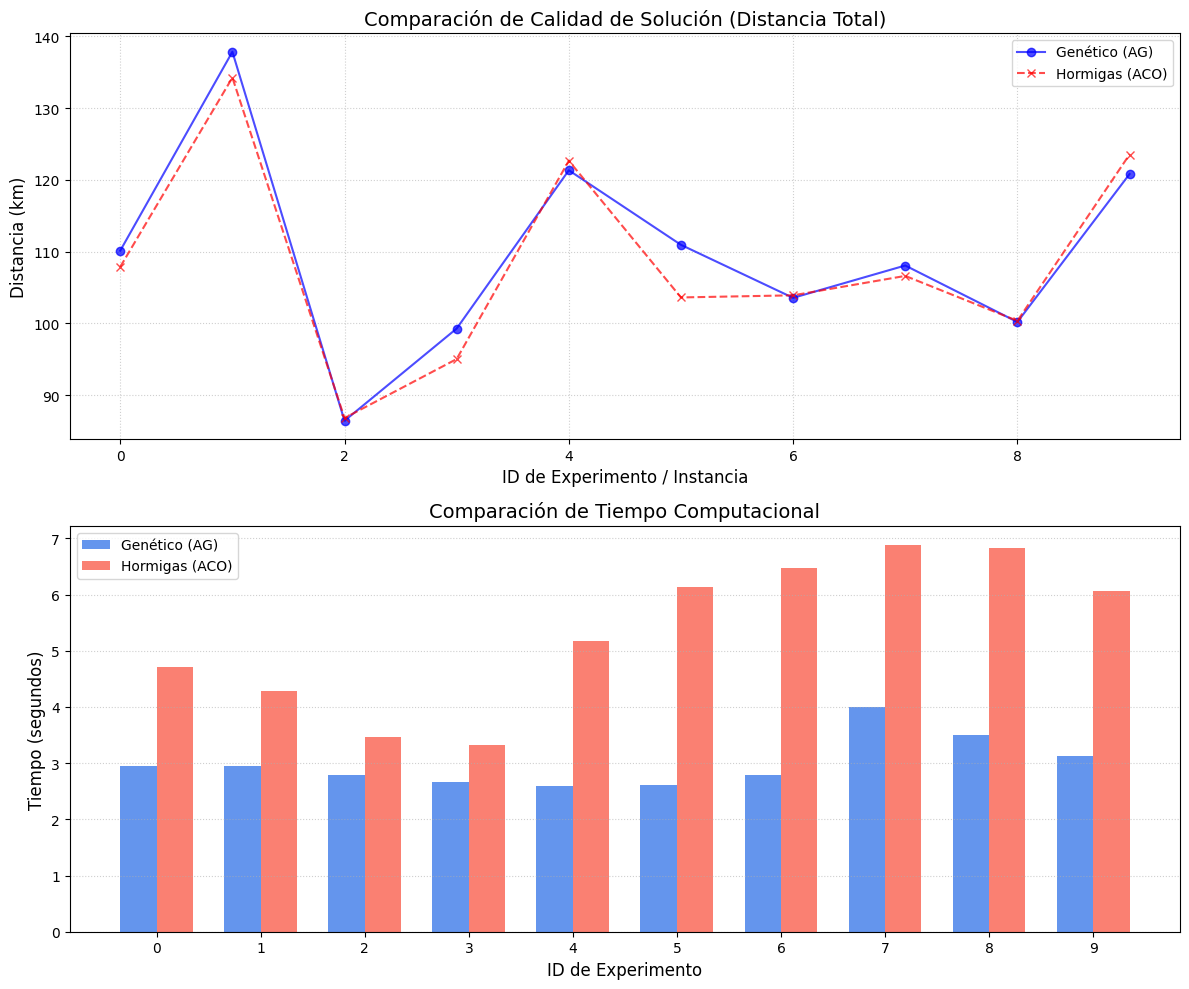

In [77]:
df = generar_reporte_completo(grafos_40)

In [78]:
df.to_csv("Reporte_Comparativo_TSP_40.csv", index=False)
df

,ID Exp,Nodos (Cant),Ref. Dirección (Nodo 0),Distancia AG,Distancia ACO,Tiempo AG (s),Tiempo ACO (s),Solucion AG,Solucion ACO,Mejor Método
0,0,40,"GAZA 1333, BEATRIZ HERNANDEZ...",110.1415,107.8880,2.9410,4.7141,"[15, 18, 1, 20, 33, 29, 11, 30, 10, 4, 26, 28,...","[23, 10, 24, 22, 25, 3, 7, 17, 35, 16, 27, 31,...",ACO
1,1,40,"CANTERA 819, SAN MARCOS...",137.8515,134.2485,2.9542,4.2845,"[14, 26, 0, 31, 38, 16, 4, 13, 12, 32, 1, 21, ...","[28, 10, 9, 34, 17, 22, 8, 2, 6, 29, 36, 24, 1...",ACO
2,2,40,"AV ESPANA 1092, MODERNA...",86.4436,86.8272,2.7821,3.4622,"[14, 28, 22, 6, 18, 29, 35, 11, 36, 19, 32, 0,...","[28, 22, 6, 17, 1, 34, 4, 9, 39, 31, 38, 0, 32...",AG
3,3,40,"WOLFANG AMADEUS 5552, RESIDENC LA ESTANC...",99.2936,95.0436,2.6692,3.3253,"[7, 25, 38, 8, 13, 4, 19, 32, 31, 27, 14, 30, ...","[2, 26, 5, 15, 10, 35, 36, 0, 18, 21, 17, 33, ...",ACO
4,4,40,"JILGEROS 33, LA VENTA DEL ASTILLE...",121.3438,122.6717,2.5901,5.1718,"[26, 13, 10, 0, 31, 3, 25, 32, 23, 2, 1, 22, 1...","[8, 37, 36, 22, 2, 23, 1, 38, 9, 35, 21, 34, 1...",AG
5,5,40,"MONTES MARCIANO 2173, SAN VICENTE...",110.9546,103.6269,2.6059,6.1326,"[9, 29, 11, 10, 18, 25, 17, 33, 34, 23, 37, 21...","[4, 8, 38, 19, 12, 14, 13, 6, 32, 30, 5, 0, 9,...",ACO
6,6,40,"ARQUIMIDES 630, HERMOSA PROVIN ZO TE...",103.5688,103.9215,2.7963,6.4727,"[35, 0, 9, 3, 16, 23, 27, 26, 17, 32, 5, 4, 20...","[33, 0, 2, 12, 16, 3, 9, 19, 6, 28, 39, 13, 8,...",AG
7,7,40,"CAMINO AL POTRE 1200, FRACC CUSPIDE...",108.0755,106.6263,3.9988,6.8785,"[5, 38, 33, 9, 7, 17, 30, 37, 11, 36, 6, 24, 2...","[13, 12, 2, 22, 25, 14, 34, 8, 31, 18, 35, 27,...",ACO
8,8,40,"PASEO DE LOS AL 79, LA MARTINICA...",100.2012,100.3660,3.4996,6.8315,"[25, 24, 26, 1, 21, 20, 3, 22, 13, 27, 38, 5, ...","[11, 39, 29, 33, 16, 28, 31, 15, 18, 19, 17, 2...",AG
9,9,40,"HERNANDO ALVARA 3254, JARDINES DEL NILO...",120.8187,123.5395,3.1336,6.0657,"[16, 34, 13, 4, 37, 26, 21, 31, 7, 30, 19, 5, ...","[7, 20, 10, 36, 23, 6, 2, 14, 32, 38, 8, 29, 2...",AG


In [ ]:
def normalizar_ciclo(ruta):
    """
    Rota la ruta para que empiece por el nodo con el ID más bajo.
    Ejemplo: [3, 5, 0, 9] -> [0, 9, 3, 5]
    """
    if not ruta: return []
    
    min_nodo = min(ruta)
    idx = ruta.index(min_nodo)
    
    ruta_rotada = ruta[idx:] + ruta[:idx]
    
    return ruta_rotada

In [79]:
df['Ruta Normalizada AG'] = df['Solucion AG'].apply(lambda x: normalizar_ciclo(eval(x)))
df['Ruta Normalizada ACO'] = df['Solucion ACO'].apply(lambda x  : normalizar_ciclo(eval(x)))
df.to_csv("Reporte_Comparativo_TSP_40.csv", index=False)

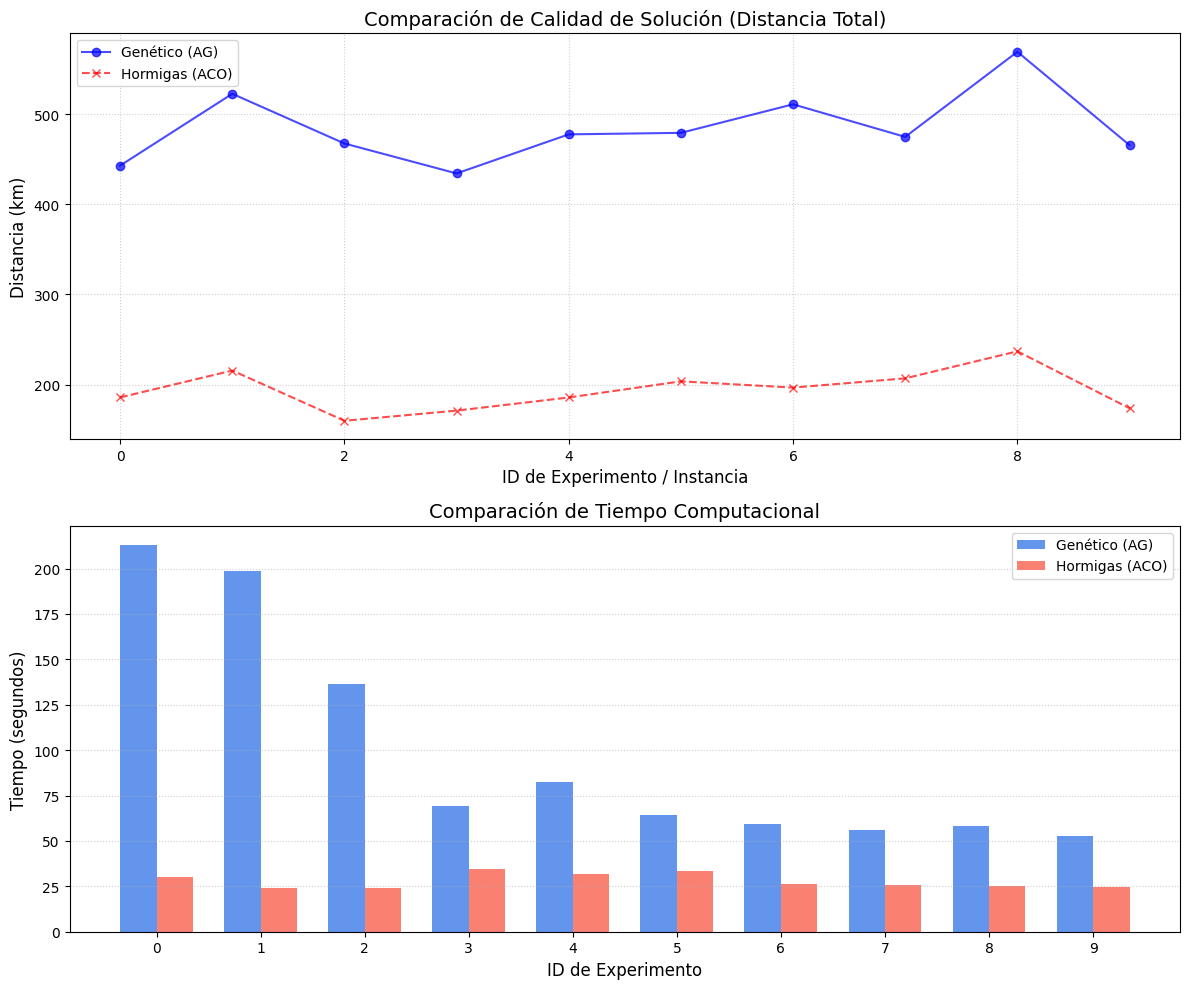

In [80]:
df = generar_reporte_completo(grafos_100)

df['Ruta Normalizada AG'] = df['Solucion AG'].apply(lambda x: normalizar_ciclo(eval(x)))
df['Ruta Normalizada ACO'] = df['Solucion ACO'].apply(lambda x  : normalizar_ciclo(eval(x)))
df.to_csv("Reporte_Comparativo_TSP_100nodos.csv", index=False)

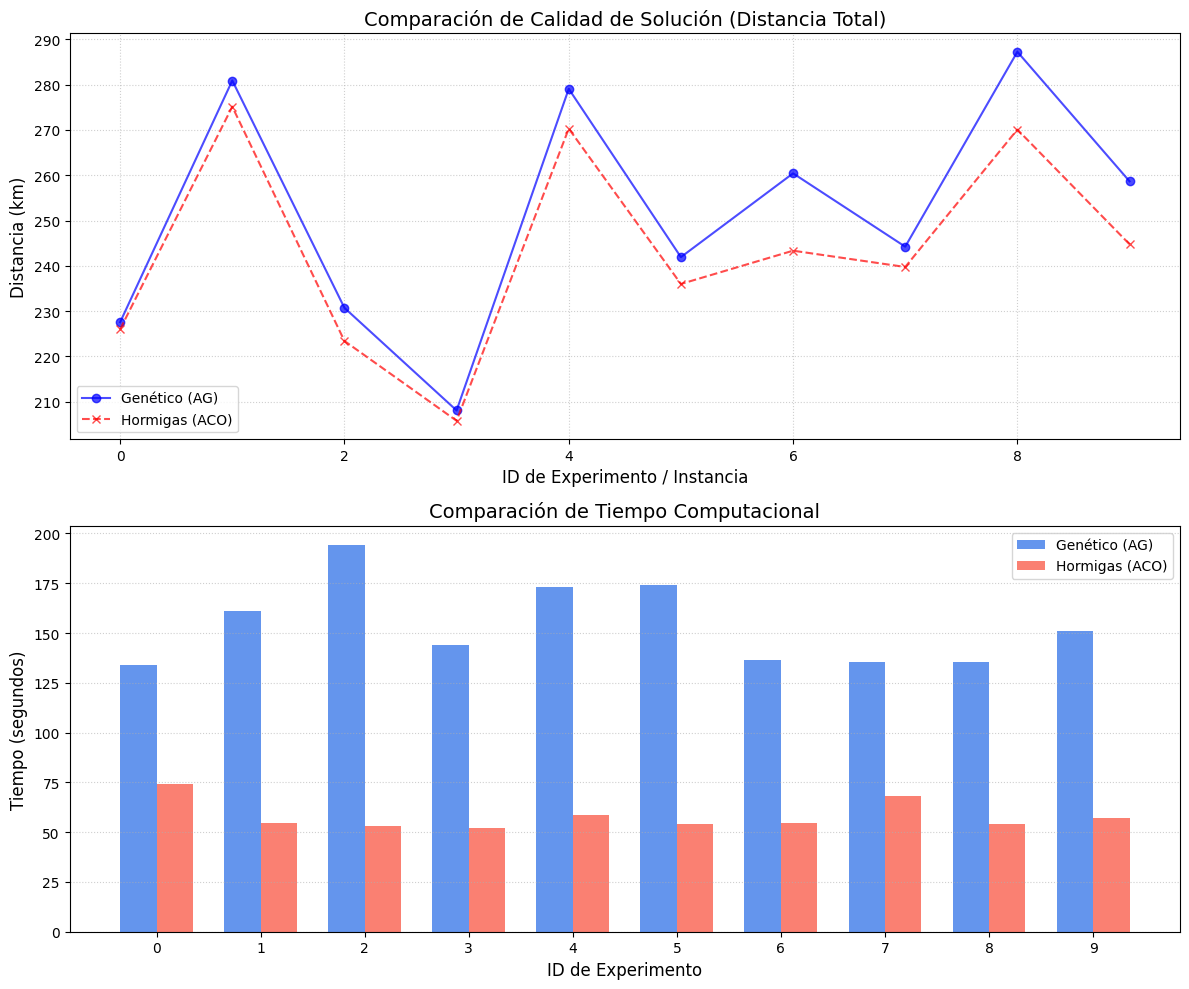

In [81]:
df = generar_reporte_completo(grafos_150)

df['Ruta Normalizada AG'] = df['Solucion AG'].apply(lambda x: normalizar_ciclo(eval(x)))
df['Ruta Normalizada ACO'] = df['Solucion ACO'].apply(lambda x  : normalizar_ciclo(eval(x)))
df.to_csv("Reporte_Comparativo_TSP_150nodos.csv", index=False)

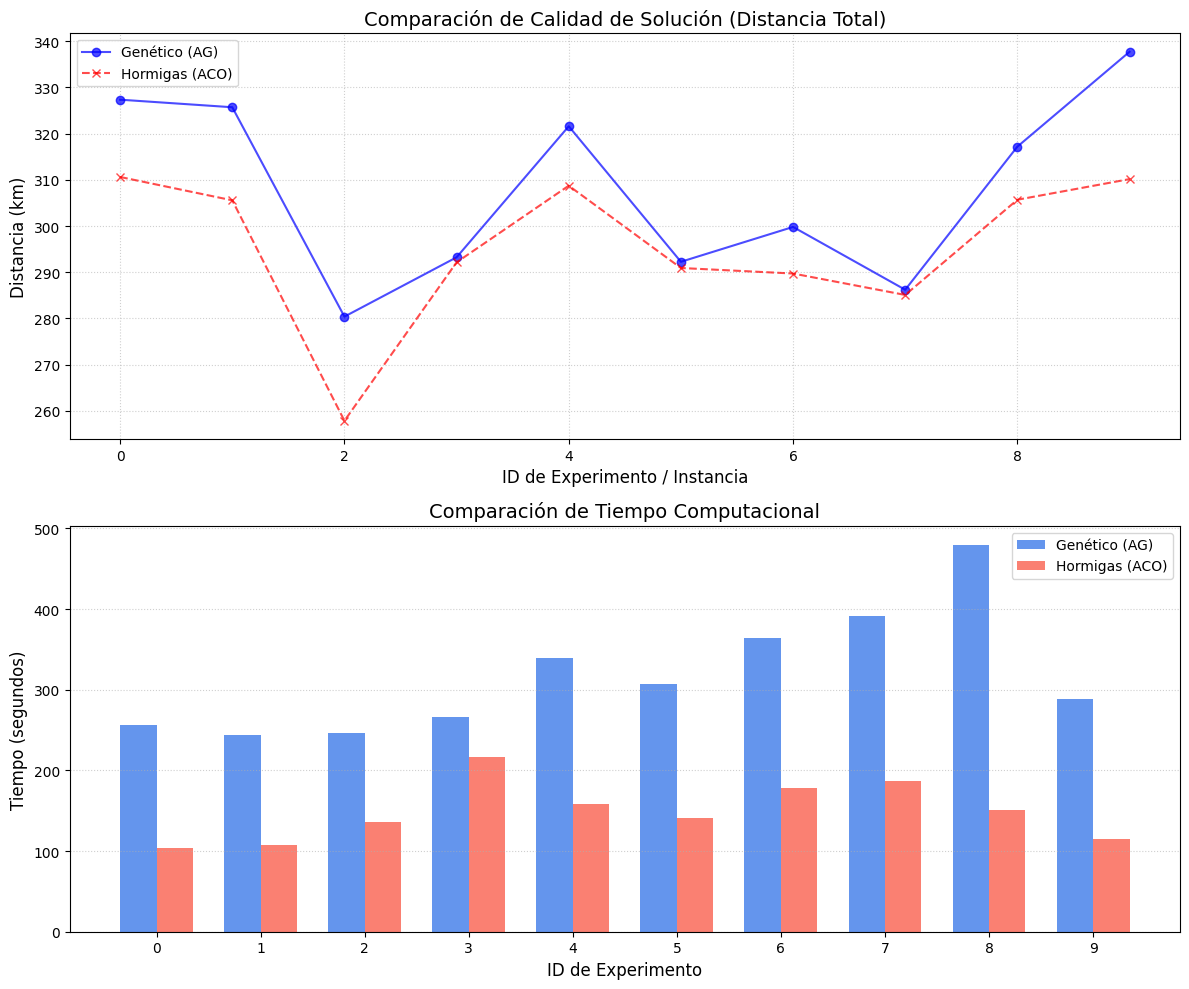

In [82]:
df = generar_reporte_completo(grafos_200)

df['Ruta Normalizada AG'] = df['Solucion AG'].apply(lambda x: normalizar_ciclo(eval(x)))
df['Ruta Normalizada ACO'] = df['Solucion ACO'].apply(lambda x  : normalizar_ciclo(eval(x)))
df.to_csv("Reporte_Comparativo_TSP_200nodos.csv", index=False)